# <font color='#ff7a5c'>Projeto Prático: Classificação de Imagens com CIFAR-100</font>

* **Aluno:** Rui Gonçalves de Oliveira Júnior
* **Matrícula:** 201910831
* **Curso:** Engenharia da Computação
* **Disciplina:** Laboratório de Inovação e Automação 1 (LIA1)
* **Data da Atividade:** 30/03/2026

 <br>

---

## <font color='#ff7a5c'>Introdução e Objetivo</font>
Este notebook documenta a construção de um modelo de aprendizado de máquina baseado em **Redes Neurais Convolucionais (CNNs)**. O objetivo é criar um sistema computacional capaz de analisar imagens e classificá-las em uma das 100 categorias distintas do dataset **CIFAR-100**.

Neste contexto, uma imagem é processada pelo algoritmo como uma matriz de pixels contendo valores de intensidade de cor.

## <font color='#ff7a5c'>Preparação do Ambiente e Bibliotecas</font>
Importação das ferramentas necessárias para manipulação de matrizes matemáticas (`numpy`), construção da arquitetura do modelo (`tensorflow.keras`) e visualização gráfica dos dados (`matplotlib` e `seaborn`).

In [ ]:
!pip install -q tensorflow

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image

print(f"Versão do TensorFlow: {tf.__version__}")

Versão do TensorFlow: 2.19.0


## <font color='#ff7a5c'>Aquisição e Tratamento dos Dados</font>
O CIFAR-100 é composto por 60.000 imagens coloridas com resolução de 32x32 pixels, divididas em 50.000 amostras para treinamento e 10.000 para teste.

Nesta etapa, os dados são carregados e normalizados. Os valores originais dos pixels (0 a 255) são divididos por 255.0 para adequação à escala entre 0 e 1, otimizando a convergência da rede neural durante o treinamento.

In [ ]:
(imagens_treino, labels_treino), (imagens_teste, labels_teste) = datasets.cifar100.load_data(label_mode='fine')

nomes_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank',
    'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

imagens_treino = imagens_treino / 255.0
imagens_teste = imagens_teste / 255.0

print(f"Formato dos dados de treino: {imagens_treino.shape}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Formato dos dados de treino: (50000, 32, 32, 3)


## <font color='#ff7a5c'>Inspeção Visual dos Dados</font>
Exibição das 25 primeiras instâncias do conjunto de treinamento e seus respectivos rótulos para validação da integridade do dataset.

Amostras do Conjunto de Treinamento:


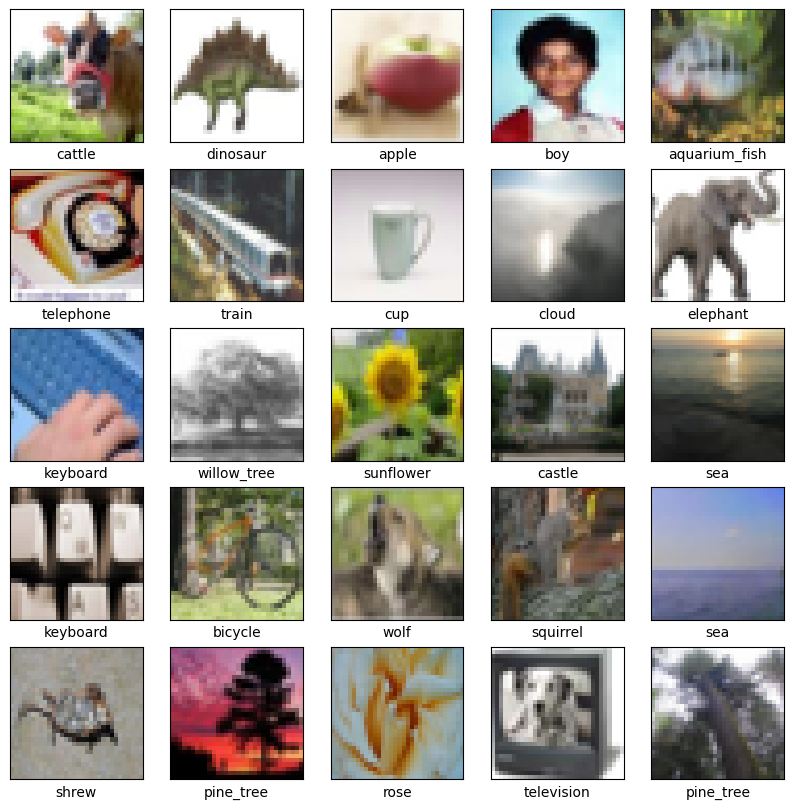

In [ ]:
def visualiza_imagens(images, labels):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(nomes_classes[labels[i][0]])
    plt.show()

print("Amostras do Conjunto de Treinamento:")
visualiza_imagens(imagens_treino, labels_treino)

## <font color='#ff7a5c'>Arquitetura do Modelo</font>
Definição da estrutura sequencial do modelo com camadas de extração de características (Feature Learning):

* **Conv2D:** Operação de convolução para detecção de padrões e características espaciais.
* **MaxPooling2D:** Redução de dimensionalidade para controle de custo computacional.
* **Flatten:** Transformação da matriz resultante em um vetor unidimensional.
* **Dense:** Camadas totalmente conectadas. A camada de saída utiliza 100 neurônios com ativação `softmax` para gerar a distribuição de probabilidade entre as 100 classes.

In [ ]:
modelo_lia = models.Sequential()

modelo_lia.add(layers.Input(shape=(32, 32, 3)))
modelo_lia.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))
modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))
modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dense(100, activation='softmax'))

modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,268 (309.64 KB)

 Trainable params: 79,268 (309.64 KB)

 Non-trainable params: 0 (0.00 B)

## <font color='#ff7a5c'>Compilação e Treinamento</font>
Configuração dos parâmetros de otimização (`adam`) e da função de perda (`sparse_categorical_crossentropy`). O treinamento é executado por 50 épocas iterativas utilizando os dados de validação para monitoramento.

In [ ]:
modelo_lia.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("Iniciando o processo de treinamento...")
history = modelo_lia.fit(imagens_treino,
                         labels_treino,
                         epochs=50,
                         validation_data=(imagens_teste, labels_teste))

Iniciando o processo de treinamento...
Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.0857 - loss: 3.9928 - val_accuracy: 0.1419 - val_loss: 3.5868
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1745 - loss: 3.4224 - val_accuracy: 0.2132 - val_loss: 3.2506
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2304 - loss: 3.1402 - val_accuracy: 0.2399 - val_loss: 3.1005
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2678 - loss: 2.9535 - val_accuracy: 0.2657 - val_loss: 2.9592
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2943 - loss: 2.8032 - val_accuracy: 0.2910 - val_loss: 2.8352
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3199 - loss: 2.6863 - val_accuracy: 0.2920 - val_loss: 2.8406
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3377 - loss: 2.6031 - val_accuracy: 0.3217 - val_loss: 2.7188
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/s

## <font color='#ff7a5c'>Análise da Convergência e Aprendizado</font>

A análise das curvas de aprendizado é fundamental para diagnosticar o comportamento da rede neural ao longo das épocas. Esta etapa plota duas métricas principais: a evolução da **Acurácia** e a minimização da **Perda (Loss)**.

O acompanhamento simultâneo das curvas de treinamento e de validação permite identificar possíveis problemas de generalização. Uma divergência significativa entre as métricas, por exemplo, a perda de treinamento continuando a cair enquanto a perda de validação estagna ou aumenta  é o principal indicativo da ocorrência de *overfitting* (sobreajuste), situação na qual o modelo memoriza os dados apresentados, mas perde a capacidade de avaliar dados inéditos.

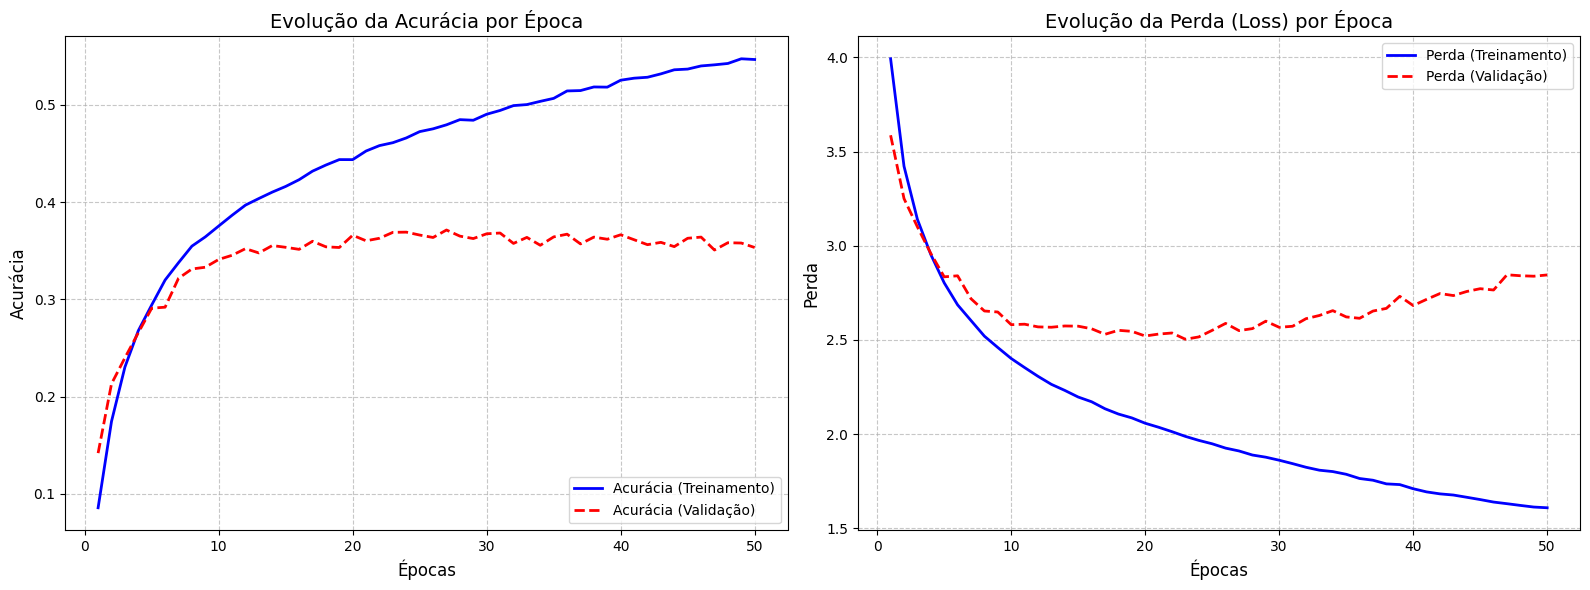

In [ ]:
import matplotlib.pyplot as plt

# Extração dos dados do histórico de treinamento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Definição do eixo X (número de épocas)
epocas = range(1, len(acc) + 1)

# Configuração da figura com dois subgráficos laterais
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Curva de Acurácia
axes[0].plot(epocas, acc, 'b-', label='Acurácia (Treinamento)', linewidth=2)
axes[0].plot(epocas, val_acc, 'r--', label='Acurácia (Validação)', linewidth=2)
axes[0].set_title('Evolução da Acurácia por Época', fontsize=14)
axes[0].set_xlabel('Épocas', fontsize=12)
axes[0].set_ylabel('Acurácia', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Curva de Perda (Loss)
axes[1].plot(epocas, loss, 'b-', label='Perda (Treinamento)', linewidth=2)
axes[1].plot(epocas, val_loss, 'r--', label='Perda (Validação)', linewidth=2)
axes[1].set_title('Evolução da Perda (Loss) por Época', fontsize=14)
axes[1].set_xlabel('Épocas', fontsize=12)
axes[1].set_ylabel('Perda', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

## <font color='#ff7a5c'>Avaliação e Análise de Desempenho</font>
Avaliação do modelo frente ao conjunto de teste para determinação da acurácia final.

Em seguida, processa-se a **Matriz de Confusão**, cruzando os valores previstos com os valores reais para identificar o padrão de acertos (diagonal principal) e as instâncias de classificação incorreta.

313/313 - 1s - 2ms/step - accuracy: 0.3534 - loss: 2.8451

Acurácia obtida no conjunto de teste: 0.3534
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


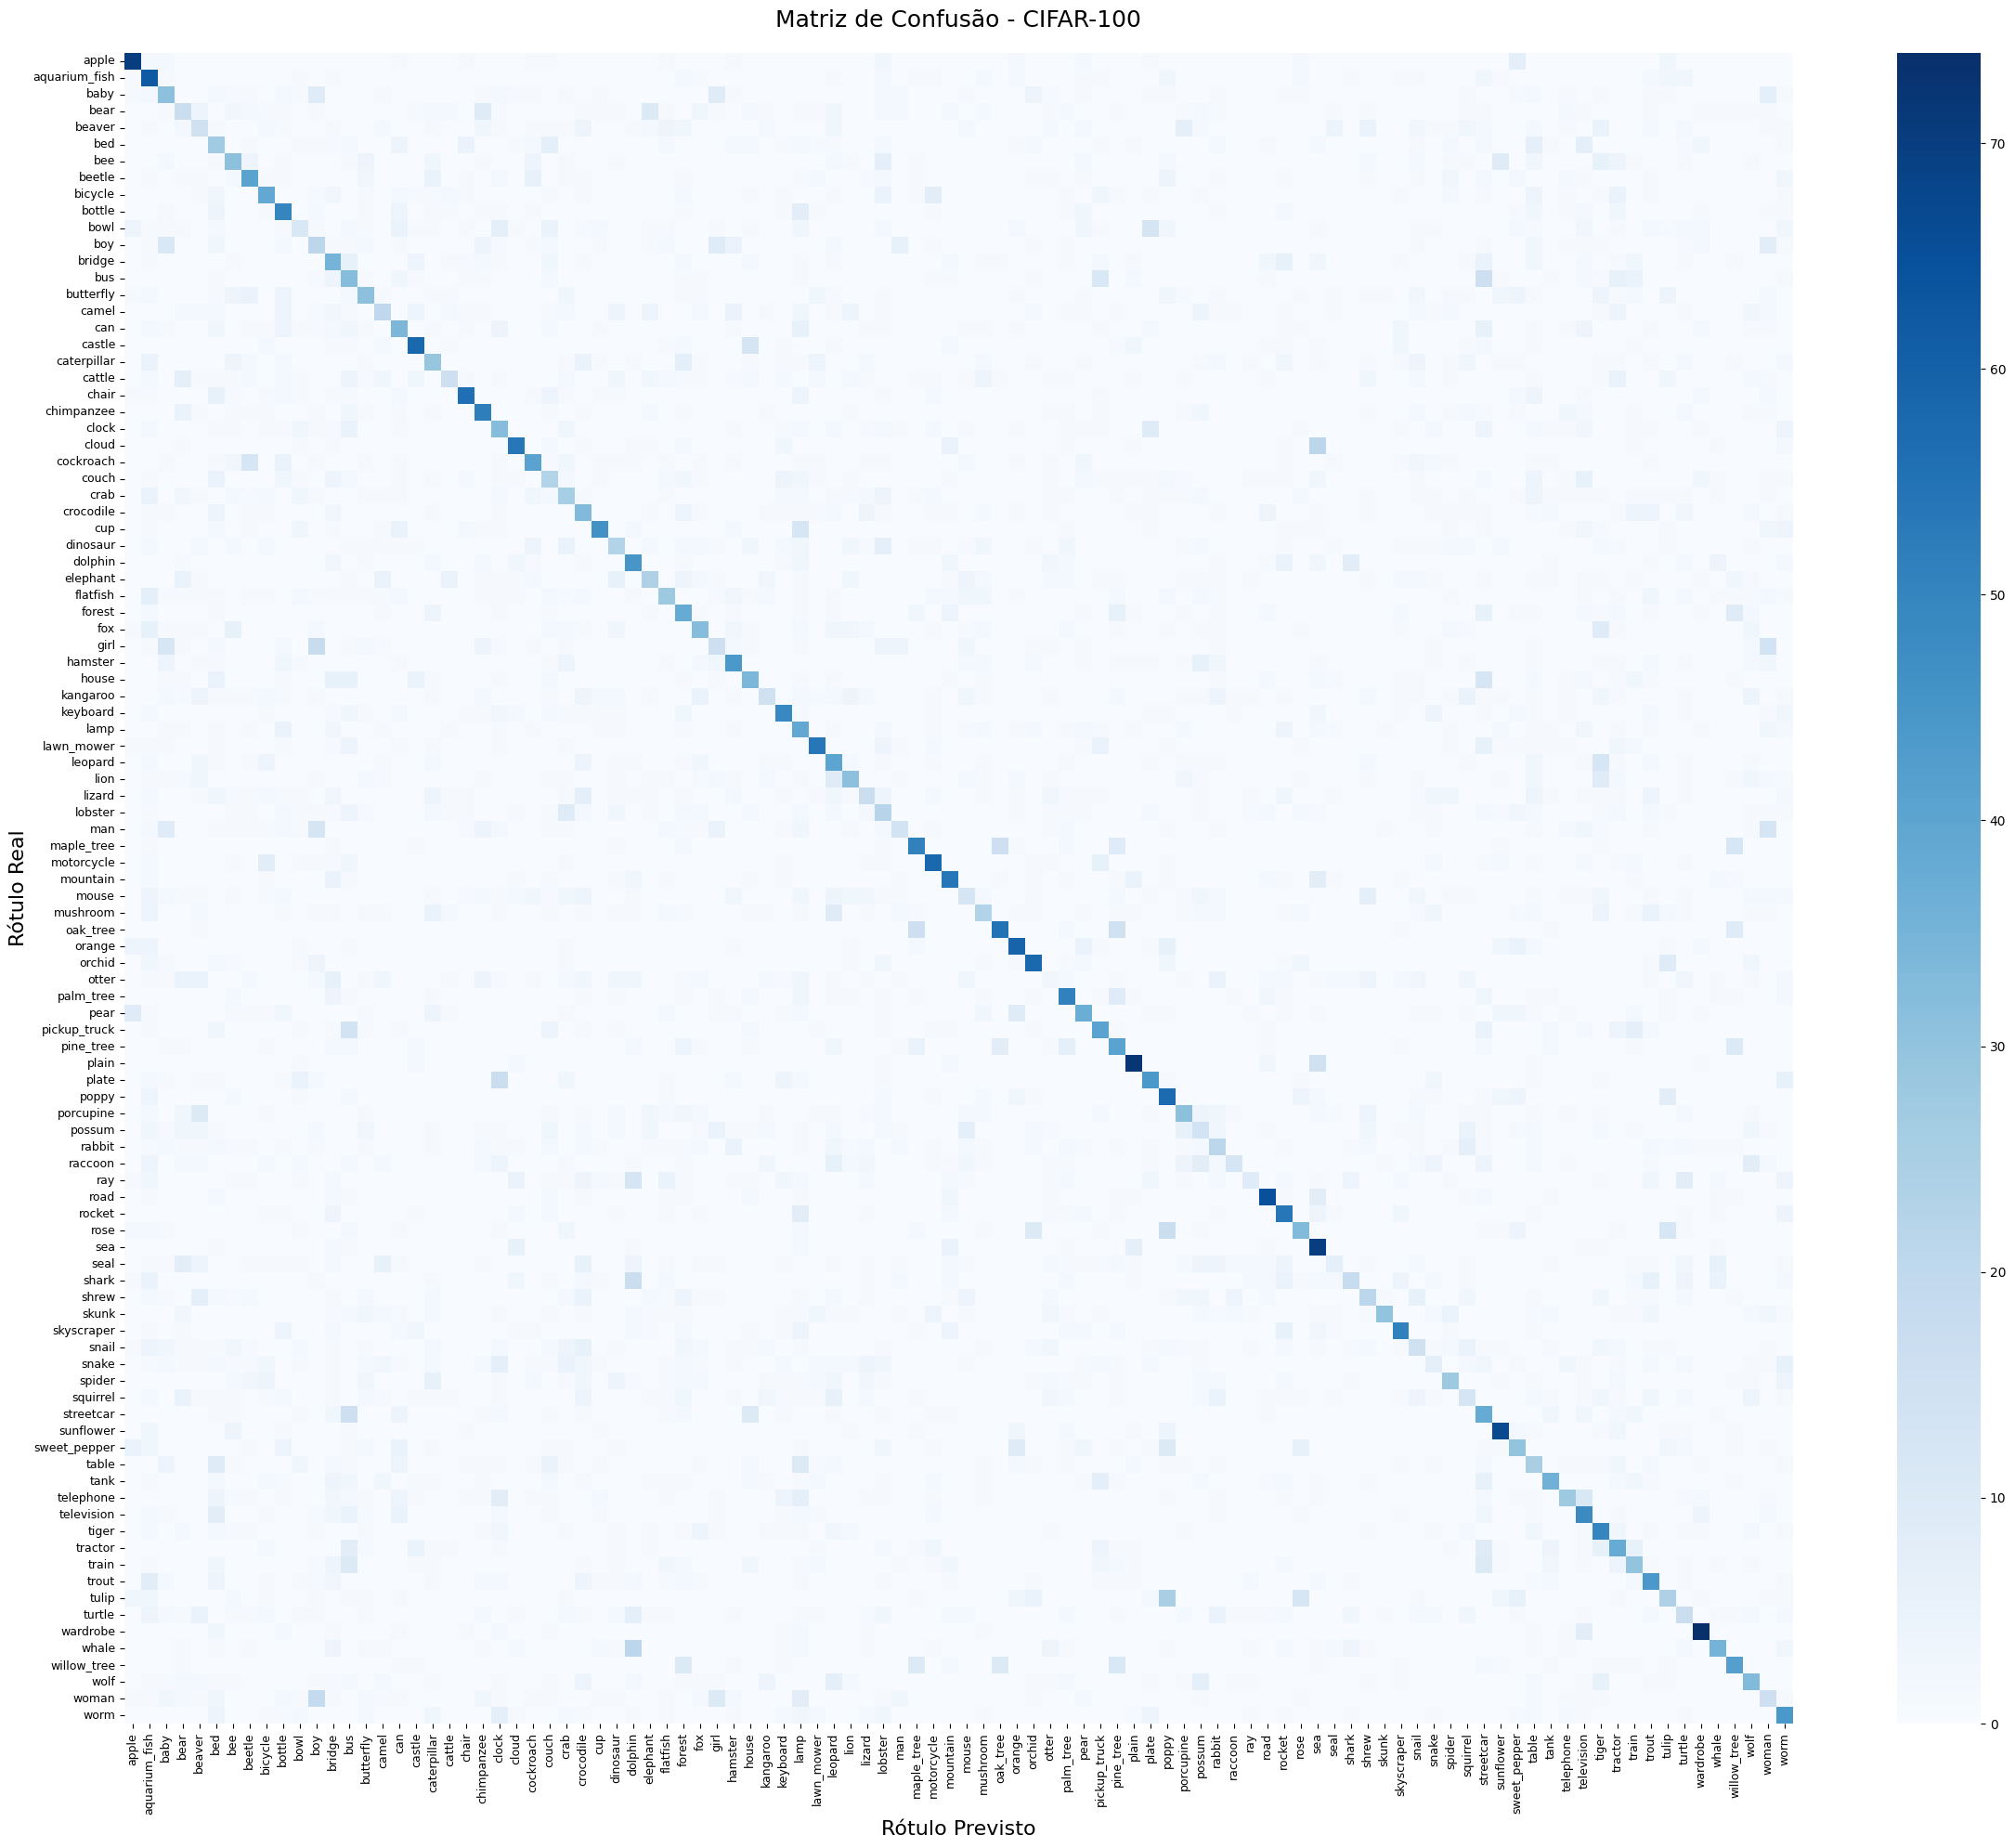

In [ ]:
from sklearn.metrics import confusion_matrix

erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose=2)
print(f"\nAcurácia obtida no conjunto de teste: {acc_teste:.4f}")

y_pred = modelo_lia.predict(imagens_teste)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = labels_teste.flatten()

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(24, 20))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes)
plt.title('Matriz de Confusão - CIFAR-100', fontsize=18, pad=20)
plt.xlabel('Rótulo Previsto', fontsize=16)
plt.ylabel('Rótulo Real', fontsize=16)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Devido à alta dimensionalidade do dataset CIFAR-100, a visualização da matriz de confusão completa torna-se inviável para uma análise direta. Como alternativa metodológica, esta etapa processa a matriz de confusão internamente para calcular a acurácia individual de cada uma das 100 classes.

Os resultados são ordenados de forma a extrair as 10 categorias com as maiores taxas de acerto e as 10 categorias com os piores desempenhos. A representação através de gráficos de barras horizontais permite identificar imediatamente quais padrões visuais o modelo consegue generalizar com eficiência e quais classes apresentam sobreposição de características, demandando potenciais ajustes na arquitetura ou aumento de dados (data augmentation).

313/313 - 1s - 2ms/step - accuracy: 0.3534 - loss: 2.8451

Acurácia global no conjunto de teste: 0.3534

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


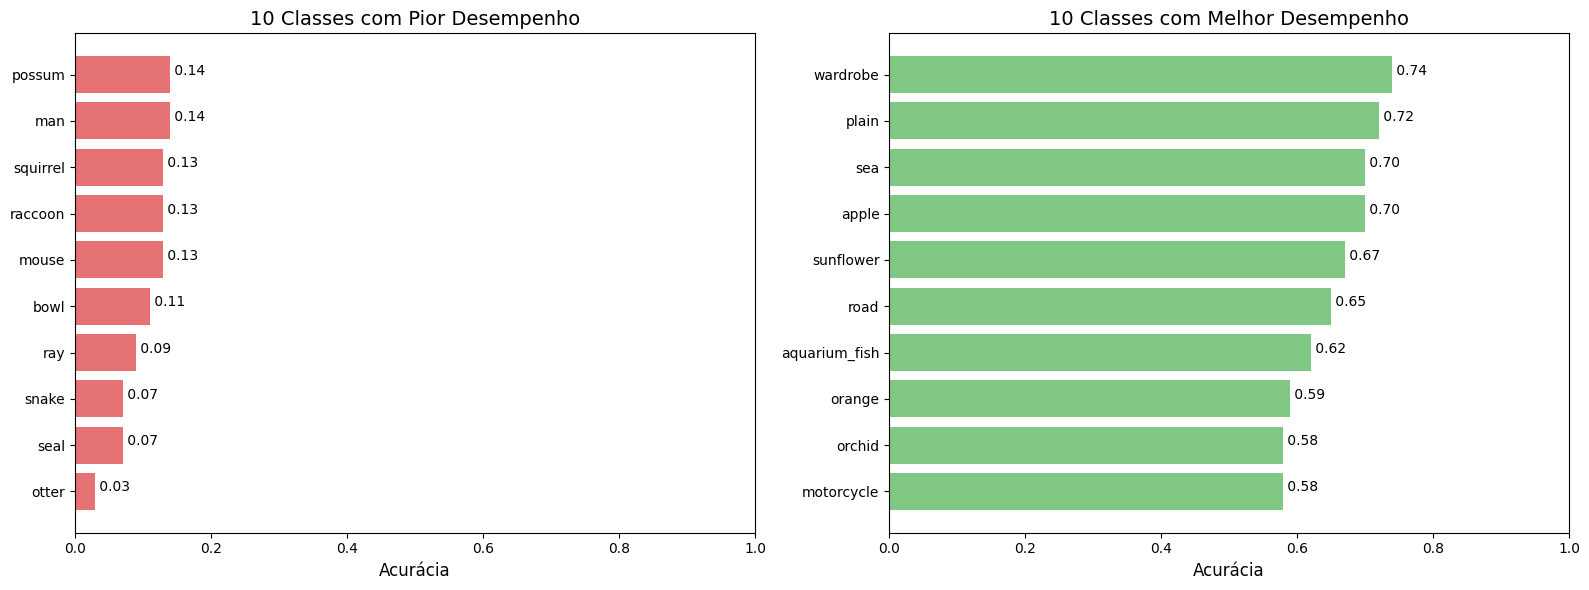

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Avaliação objetiva no conjunto de teste
erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose=2)
print(f"\nAcurácia global no conjunto de teste: {acc_teste:.4f}\n")

# Gerando as previsões
y_pred = modelo_lia.predict(imagens_teste)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = labels_teste.flatten()

# Cálculo da matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

# Cálculo da acurácia por classe (Diagonal principal dividida pelo total da linha)
acuracia_por_classe = cm.diagonal() / cm.sum(axis=1)

# Associação das acurácias aos nomes das classes
desempenho_classes = list(zip(nomes_classes, acuracia_por_classe))

# Ordenação dos resultados do pior para o melhor
desempenho_classes.sort(key=lambda x: x[1])

# Extração dos extremos
piores_10 = desempenho_classes[:10]
melhores_10 = desempenho_classes[-10:]

classes_piores, acc_piores = zip(*piores_10)
classes_melhores, acc_melhores = zip(*melhores_10)

# Configuração da plotagem
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Piores Desempenhos
axes[0].barh(classes_piores, acc_piores, color='#e57373')
axes[0].set_title('10 Classes com Pior Desempenho', fontsize=14)
axes[0].set_xlabel('Acurácia', fontsize=12)
axes[0].set_xlim(0, 1)
for index, value in enumerate(acc_piores):
    axes[0].text(value, index, f' {value:.2f}')

# Gráfico 2: Melhores Desempenhos
axes[1].barh(classes_melhores, acc_melhores, color='#81c784')
axes[1].set_title('10 Classes com Melhor Desempenho', fontsize=14)
axes[1].set_xlabel('Acurácia', fontsize=12)
axes[1].set_xlim(0, 1)
for index, value in enumerate(acc_melhores):
    axes[1].text(value, index, f' {value:.2f}')

plt.tight_layout()
plt.show()

## <font color='#ff7a5c'>Análise de Erros: Pares de Maior e Menor Confusão</font>

Para compreender as limitações de extração de características da rede neural, é necessário investigar quais classes específicas geram maior ambiguidade. Esta etapa isola os erros do modelo (falsos positivos e falsos negativos) ao zerar a diagonal principal da matriz de confusão.

O gráfico gerado ilustra os 10 pares de imagens que o modelo mais confundiu (por exemplo, a imagem real era de uma classe, mas a rede previu outra devido à similaridade de bordas, cores ou texturas).

Em contrapartida, os pares que o modelo "menos se confundiu" representam cruzamentos com zero ocorrências de erro. Em um dataset com 100 classes, existem milhares de combinações perfeitamente distinguidas pela IA (ex: o modelo jamais confunde um 'maçã' com um 'trator'). O código abaixo lista alguns exemplos reais dessas classes perfeitamente separadas pelo modelo.

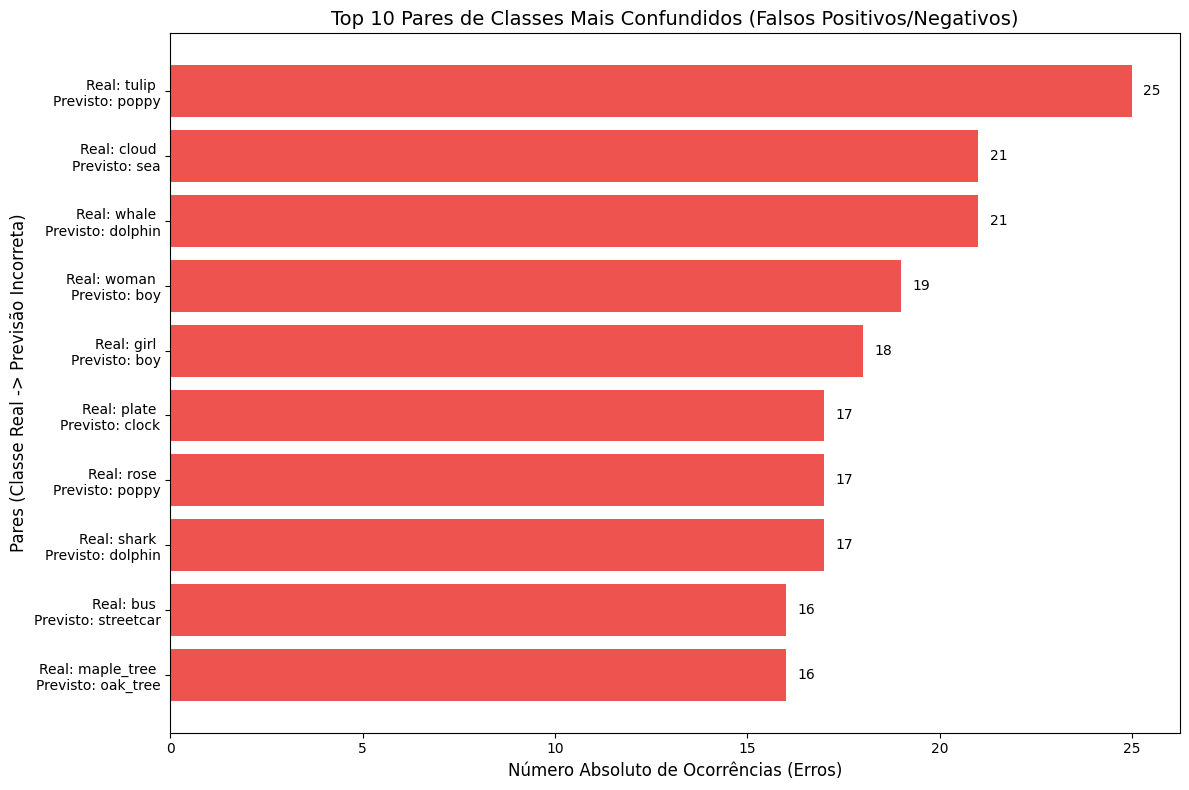


EXEMPLOS DE PARES COM MENOR CONFUSÃO (ZERO ERROS REGISTRADOS):
 -> O modelo NUNCA confundiu a classe real 'APPLE' com 'BEAR'.
 -> O modelo NUNCA confundiu a classe real 'CHAIR' com 'LEOPARD'.
 -> O modelo NUNCA confundiu a classe real 'LAWN_MOWER' com 'CHAIR'.
 -> O modelo NUNCA confundiu a classe real 'PLAIN' com 'MAPLE_TREE'.
 -> O modelo NUNCA confundiu a classe real 'SQUIRREL' com 'SHREW'.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Criação de uma cópia da matriz de confusão para preservação dos dados originais
cm_erros = cm.copy()

# Zerar a diagonal principal (acertos) para analisar estritamente os erros de classificação
np.fill_diagonal(cm_erros, 0)

# Mapeamento de todos os pares de erros ocorridos
pares_erro = []
pares_perfeitos = []

for i in range(cm_erros.shape[0]):
    for j in range(cm_erros.shape[1]):
        if i != j:
            if cm_erros[i, j] > 0:
                pares_erro.append((nomes_classes[i], nomes_classes[j], cm_erros[i, j]))
            else:
                pares_perfeitos.append((nomes_classes[i], nomes_classes[j]))

# Ordenação decrescente para obter as maiores confusões
pares_erro.sort(key=lambda x: x[2], reverse=True)

# Seleção dos 10 maiores erros
top_10_erros = pares_erro[:10]
labels_erros = [f"Real: {p[0]} \nPrevisto: {p[1]}" for p in top_10_erros]
valores_erros = [p[2] for p in top_10_erros]

# Configuração e plotagem do gráfico de barras horizontais
plt.figure(figsize=(12, 8))
bars = plt.barh(labels_erros[::-1], valores_erros[::-1], color='#ef5350')
plt.title('Top 10 Pares de Classes Mais Confundidos (Falsos Positivos/Negativos)', fontsize=14)
plt.xlabel('Número Absoluto de Ocorrências (Erros)', fontsize=12)
plt.ylabel('Pares (Classe Real -> Previsão Incorreta)', fontsize=12)

# Adição dos rótulos de dados nas barras
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

# Exibição de pares com distinção perfeita (zero erros de confusão direta)
print("\n" + "="*70)
print("EXEMPLOS DE PARES COM MENOR CONFUSÃO (ZERO ERROS REGISTRADOS):")
print("="*70)

# Seleciona 5 exemplos distribuídos ao longo da lista de pares sem erros
passo = max(1, len(pares_perfeitos) // 5)
for par in pares_perfeitos[::passo][:5]:
    print(f" -> O modelo NUNCA confundiu a classe real '{par[0].upper()}' com '{par[1].upper()}'.")
print("="*70)

## <font color='#ff7a5c'>Inferência</font>
Teste prático do modelo com uma nova imagem externa. O arquivo passa pelo redimensionamento (32x32) e normalização correspondentes aos dados de treinamento antes da aplicação do método `predict`.

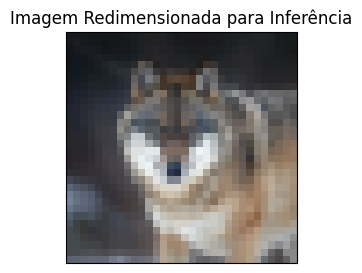

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
RESULTADO DA INFERÊNCIA
Classificação: WOLF
Nível de Confiança: 81.29%


In [ ]:
caminho_imagem = "/content/img1.png"

try:
    nova_imagem = Image.open(caminho_imagem).convert('RGB')
    nova_imagem_resized = nova_imagem.resize((32, 32))

    plt.figure(figsize=(3,3))
    plt.imshow(nova_imagem_resized)
    plt.xticks([])
    plt.yticks([])
    plt.title("Imagem Redimensionada para Inferência")
    plt.show()

    nova_imagem_array = np.array(nova_imagem_resized) / 255.0
    nova_imagem_array = np.expand_dims(nova_imagem_array, axis=0)

    previsoes = modelo_lia.predict(nova_imagem_array)

    classe_prevista = np.argmax(previsoes)
    nome_classe_prevista = nomes_classes[classe_prevista]
    confianca = np.max(previsoes) * 100

    print("="*50)
    print("RESULTADO DA INFERÊNCIA")
    print(f"Classificação: {nome_classe_prevista.upper()}")
    print(f"Nível de Confiança: {confianca:.2f}%")
    print("="*50)

except FileNotFoundError:
    print(f"\nERRO: O arquivo '{caminho_imagem}' não foi localizado no diretório especificado.")
    print("Realize o upload do arquivo para o ambiente de execução e tente novamente.")

## <font color='#ff7a5c'>Tradução das Categorias do CIFAR-100</font>

O dataset CIFAR-100 foi originalmente catalogado em inglês. Para facilitar a análise interpretativa dos resultados, da matriz de confusão e das inferências do modelo, a tabela abaixo apresenta a tradução direta das 100 classes utilizadas no treinamento para o português do Brasil.

| Inglês (Original) | Tradução (Português) | | Inglês (Original) | Tradução (Português) |
| :--- | :--- | :---| :--- | :--- |
| **apple** | maçã | | **aquarium_fish** | peixe de aquário |
| **baby** | bebê | | **bear** | urso |
| **beaver** | castor | | **bed** | cama |
| **bee** | abelha | | **beetle** | besouro |
| **bicycle** | bicicleta | | **bottle** | garrafa |
| **bowl** | tigela | | **boy** | menino |
| **bridge** | ponte | | **bus** | ônibus |
| **butterfly** | borboleta | | **camel** | camelo |
| **can** | lata | | **castle** | castelo |
| **caterpillar** | lagarta | | **cattle** | gado |
| **chair** | cadeira | | **chimpanzee** | chimpanzé |
| **clock** | relógio | | **cloud** | nuvem |
| **cockroach** | barata | | **couch** | sofá |
| **crab** | caranguejo | | **crocodile** | crocodilo |
| **cup** | xícara / copo | | **dinosaur** | dinossauro |
| **dolphin** | golfinho | | **elephant** | elefante |
| **flatfish** | linguado | | **forest** | floresta |
| **fox** | raposa | | **girl** | menina |
| **hamster** | hamster | | **house** | casa |
| **kangaroo** | canguru | | **keyboard** | teclado |
| **lamp** | abajur / lâmpada | | **lawn_mower** | cortador de grama |
| **leopard** | leopardo | | **lion** | leão |
| **lizard** | lagarto | | **lobster** | lagosta |
| **man** | homem | | **maple_tree** | bordo (árvore) |
| **motorcycle** | motocicleta | | **mountain** | montanha |
| **mouse** | rato / camundongo | | **mushroom** | cogumelo |
| **oak_tree** | carvalho (árvore) | | **orange** | laranja |
| **orchid** | orquídea | | **otter** | lontra |
| **palm_tree** | palmeira | | **pear** | pera |
| **pickup_truck** | caminhonete | | **pine_tree** | pinheiro |
| **plain** | planície | | **plate** | prato |
| **poppy** | papoula | | **porcupine** | porco-espinho |
| **possum** | gambá | | **rabbit** | coelho |
| **raccoon** | guaxinim | | **ray** | arraia |
| **road** | estrada | | **rocket** | foguete |
| **rose** | rosa | | **sea** | mar |
| **seal** | foca | | **shark** | tubarão |
| **shrew** | musaranho | | **skunk** | cangambá |
| **skyscraper** | arranha-céu | | **snail** | caracol |
| **snake** | cobra | | **spider** | aranha |
| **squirrel** | esquilo | | **streetcar** | bonde |
| **sunflower** | girassol | | **sweet_pepper** | pimentão |
| **table** | mesa | | **tank** | tanque de guerra |
| **telephone** | telefone | | **television** | televisão |
| **tiger** | tigre | | **tractor** | trator |
| **train** | trem | | **trout** | truta |
| **tulip** | tulipa | | **turtle** | tartaruga |
| **wardrobe** | guarda-roupa | | **whale** | baleia |
| **willow_tree** | salgueiro (árvore) | | **wolf** | lobo |
| **woman** | mulher | | **worm** | minhoca |